# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Student Lifestyle Academic Performance Dataset](https://www.kaggle.com/datasets/shyamnadhs/student-lifestyle-and-academic-performance-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

/kaggle/input/datasets/shyamnadhs/student-lifestyle-and-academic-performance-dataset/student_lifestyle_academic_performance_dataset.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('student_lifestyle_academic_performance_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,student_id,age,gender,study_hours_per_day,sleep_hours_per_day,social_media_hours,exercise_hours_per_week,attendance_percentage,internet_access,part_time_job,stress_level,assignment_completion_rate,exam_score,cgpa,academic_performance
0,1,17,Male,2.7,NaN,3.5,2.4,85.7,Yes,Yes,Medium,100.0,63.8,2.87,Average
1,2,23,Male,3.2,5.9,2.1,7.5,65.0,Yes,No,Medium,100.0,59.8,2.44,Average
2,3,22,Male,3.6,6.1,1.3,1.3,87.0,Yes,No,Medium,100.0,74.5,2.85,Average
3,4,20,Male,4.4,6.1,0.9,7.2,73.8,Yes,No,High,100.0,75.2,2.50,Average
4,5,20,Female,5.1,7.6,0.0,2.0,94.8,Yes,No,Medium,NaN,86.5,3.76,Good


## last Five row

In [4]:
df.tail()

,student_id,age,gender,study_hours_per_day,sleep_hours_per_day,social_media_hours,exercise_hours_per_week,attendance_percentage,internet_access,part_time_job,stress_level,assignment_completion_rate,exam_score,cgpa,academic_performance
1517,608,21,Male,0.6,9.5,2.7,0.4,79.4,Yes,No,Medium,92.2,68.5,2.86,Average
1518,434,18,Male,3.5,6.9,4.7,3.2,92.5,Yes,No,Medium,NaN,80.6,3.84,Good
1519,52,18,Male,3.4,6.2,5.6,3.7,80.3,No,Yes,Medium,100.0,81.8,3.07,Average
1520,1200,22,Female,2.8,6.5,4.3,8.1,81.8,Yes,No,High,94.4,66.4,2.36,Average
1521,1129,22,Female,2.5,8.5,4.8,6.3,63.4,Yes,No,Low,90.9,57.0,2.28,Average


## Shape of our dataset

In [5]:
df.shape

(1522, 15)

## List out all columns

In [6]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'sleep_hours_per_day', 'social_media_hours', 'exercise_hours_per_week',
       'attendance_percentage', 'internet_access', 'part_time_job',
       'stress_level', 'assignment_completion_rate', 'exam_score', 'cgpa',
       'academic_performance'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

student_id                      int64
age                             int64
gender                         object
study_hours_per_day           float64
sleep_hours_per_day           float64
social_media_hours            float64
exercise_hours_per_week       float64
attendance_percentage         float64
internet_access                object
part_time_job                  object
stress_level                   object
assignment_completion_rate    float64
exam_score                    float64
cgpa                          float64
academic_performance           object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1522 entries, 0 to 1521
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1522 non-null   int64  
 1   age                         1522 non-null   int64  
 2   gender                      1522 non-null   object 
 3   study_hours_per_day         1522 non-null   float64
 4   sleep_hours_per_day         1448 non-null   float64
 5   social_media_hours          1522 non-null   float64
 6   exercise_hours_per_week     1447 non-null   float64
 7   attendance_percentage       1522 non-null   float64
 8   internet_access             1522 non-null   object 
 9   part_time_job               1522 non-null   object 
 10  stress_level                1522 non-null   object 
 11  assignment_completion_rate  1446 non-null   float64
 12  exam_score                  1522 non-null   float64
 13  cgpa                        1522 

## Check Null Value

In [9]:
df.isnull().sum()

student_id                     0
age                            0
gender                         0
study_hours_per_day            0
sleep_hours_per_day           74
social_media_hours             0
exercise_hours_per_week       75
attendance_percentage          0
internet_access                0
part_time_job                  0
stress_level                   0
assignment_completion_rate    76
exam_score                     0
cgpa                           0
academic_performance           0
dtype: int64

## Fill numeric null values with median

In [10]:
df['sleep_hours_per_day'] = df['sleep_hours_per_day'].fillna(df['sleep_hours_per_day'].median())
df['exercise_hours_per_week'] = df['exercise_hours_per_week'].fillna(df['exercise_hours_per_week'].median())
df['assignment_completion_rate'] = df['assignment_completion_rate'].fillna(df['assignment_completion_rate'].median())

## Check Dupicate Value

In [11]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,student_id,age,study_hours_per_day,sleep_hours_per_day,social_media_hours,exercise_hours_per_week,attendance_percentage,assignment_completion_rate,exam_score,cgpa
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000
mean,750.500000,21.044667,3.595000,6.931400,3.142133,3.998667,81.712200,96.38560,72.601800,2.901987
std,433.157015,2.583884,1.597324,1.181724,1.811791,1.898614,9.861069,7.26991,14.431684,0.657420
min,1.000000,17.000000,0.500000,2.000000,0.000000,0.000000,46.700000,46.50000,30.800000,0.770000
25%,375.750000,19.000000,2.500000,6.200000,1.900000,2.800000,75.300000,96.30000,62.400000,2.447500
50%,750.500000,21.000000,3.600000,6.900000,3.050000,3.900000,81.750000,100.00000,72.450000,2.920000
75%,1125.250000,23.000000,4.600000,7.700000,4.300000,5.200000,88.625000,100.00000,83.700000,3.410000
max,1500.000000,25.000000,15.000000,10.000000,12.000000,12.100000,100.000000,100.00000,100.000000,4.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

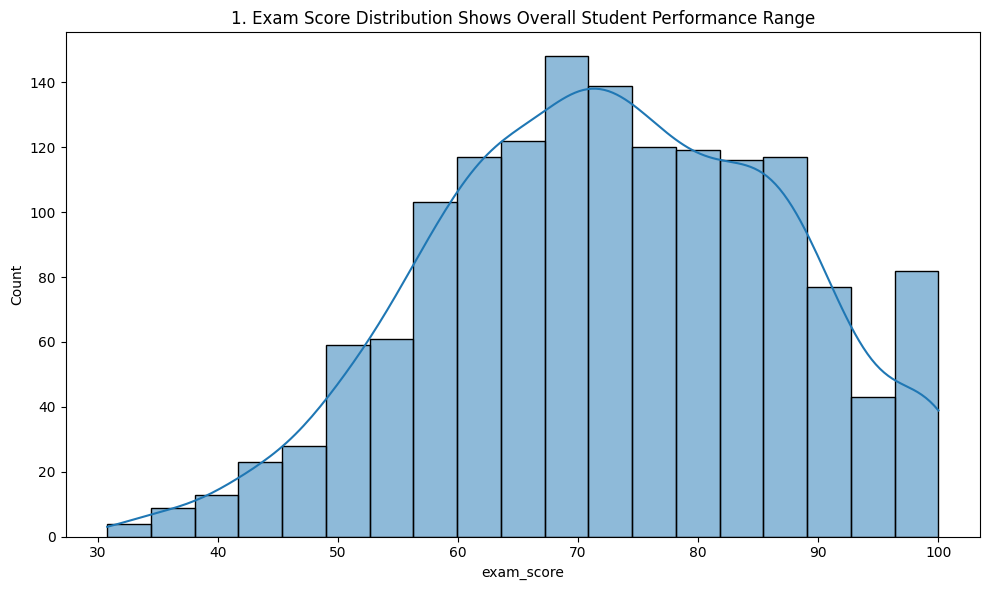

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['exam_score'], kde=True)
plt.title(f'{plot_no}. Exam Score Distribution Shows Overall Student Performance Range')
show_fig()
plot_no += 1

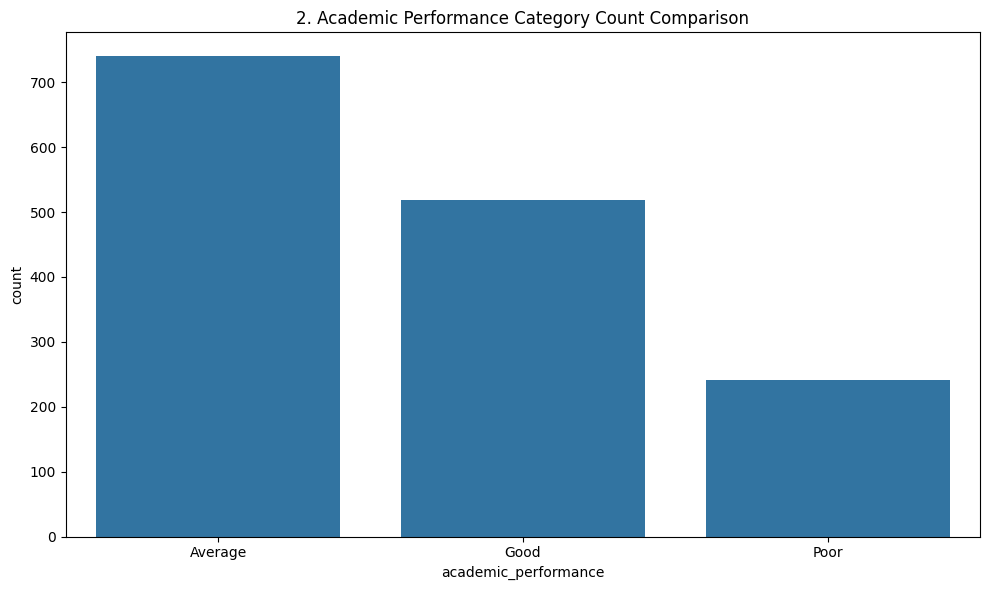

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='academic_performance')
plt.title(f'{plot_no}. Academic Performance Category Count Comparison')
show_fig()
plot_no += 1

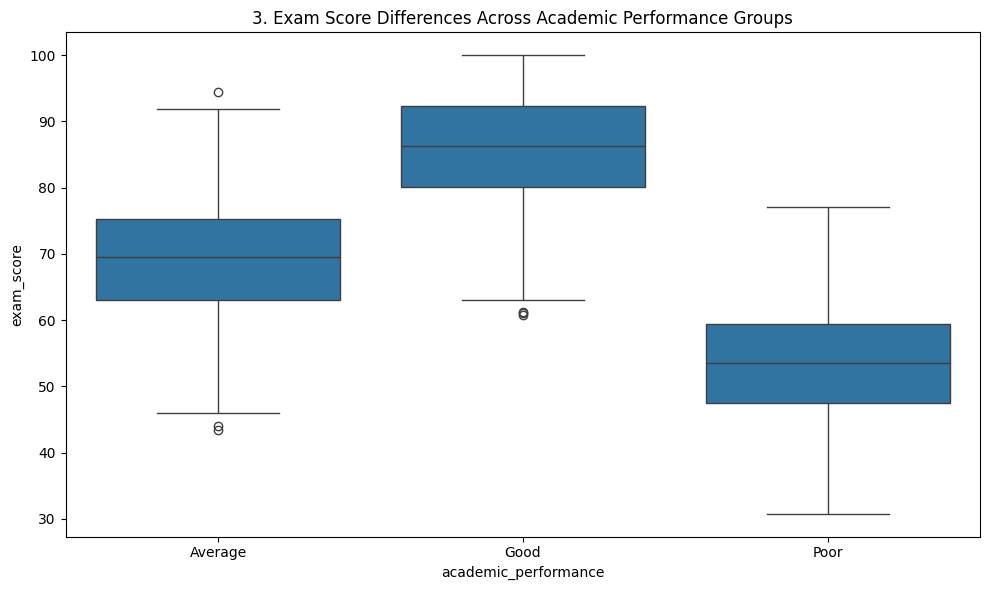

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='academic_performance', y='exam_score')
plt.title(f'{plot_no}. Exam Score Differences Across Academic Performance Groups')
show_fig()
plot_no += 1

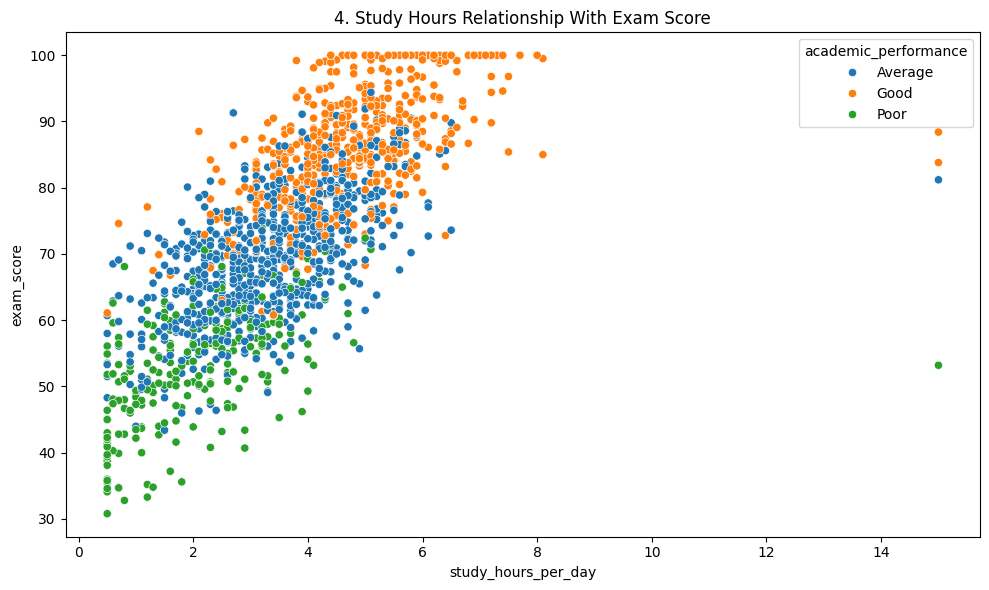

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='study_hours_per_day', y='exam_score', hue='academic_performance')
plt.title(f'{plot_no}. Study Hours Relationship With Exam Score')
show_fig()
plot_no += 1

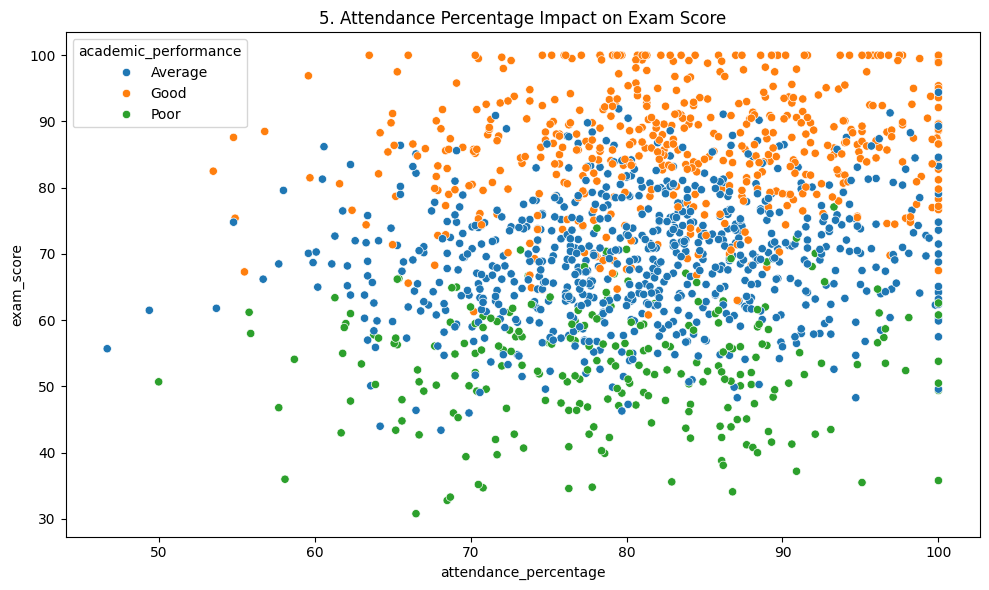

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='attendance_percentage', y='exam_score', hue='academic_performance')
plt.title(f'{plot_no}. Attendance Percentage Impact on Exam Score')
show_fig()
plot_no += 1

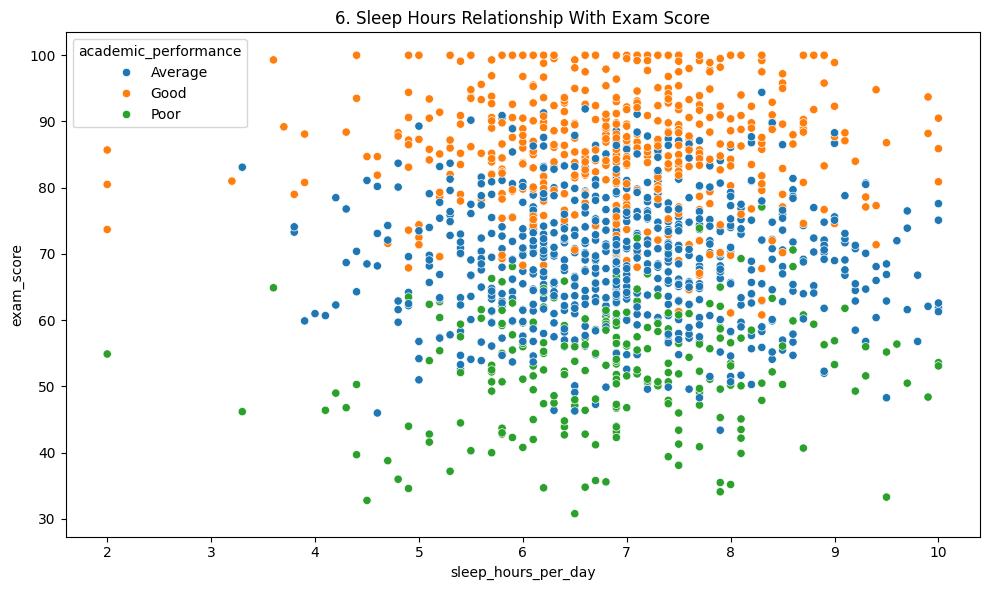

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='sleep_hours_per_day', y='exam_score', hue='academic_performance')
plt.title(f'{plot_no}. Sleep Hours Relationship With Exam Score')
show_fig()
plot_no += 1

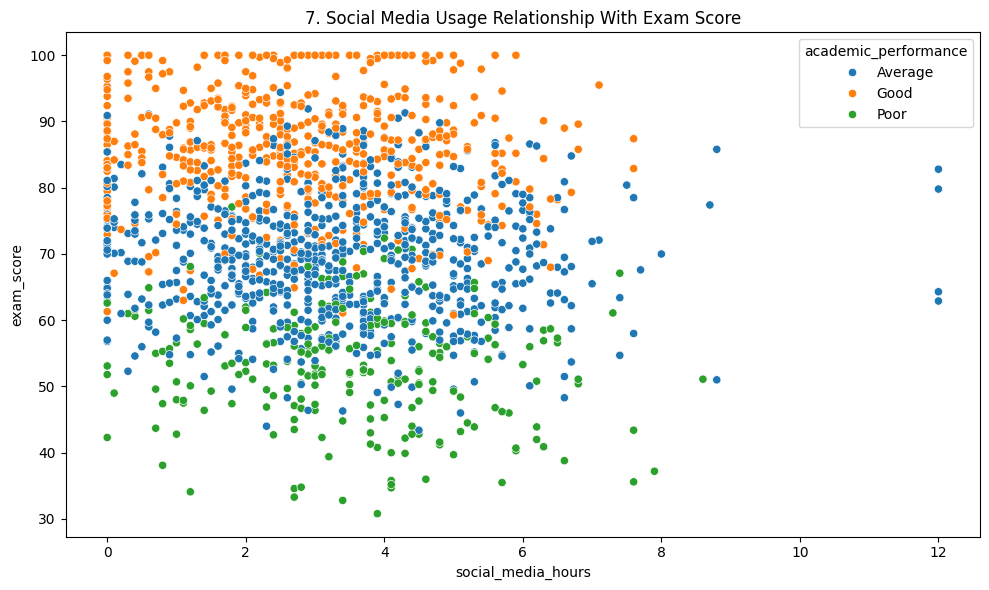

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='social_media_hours', y='exam_score', hue='academic_performance')
plt.title(f'{plot_no}. Social Media Usage Relationship With Exam Score')
show_fig()
plot_no += 1

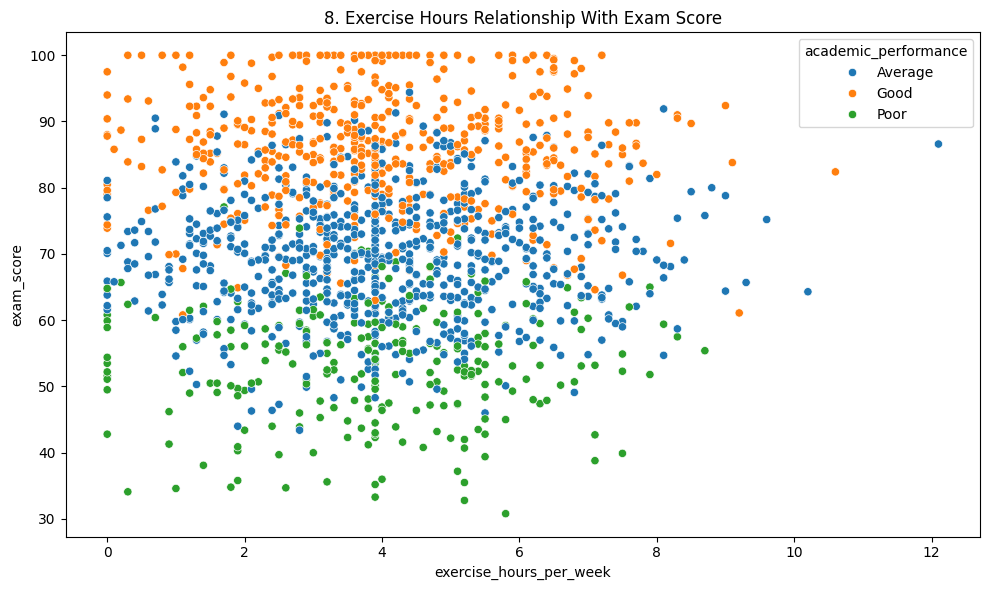

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='exercise_hours_per_week', y='exam_score', hue='academic_performance')
plt.title(f'{plot_no}. Exercise Hours Relationship With Exam Score')
show_fig()
plot_no += 1

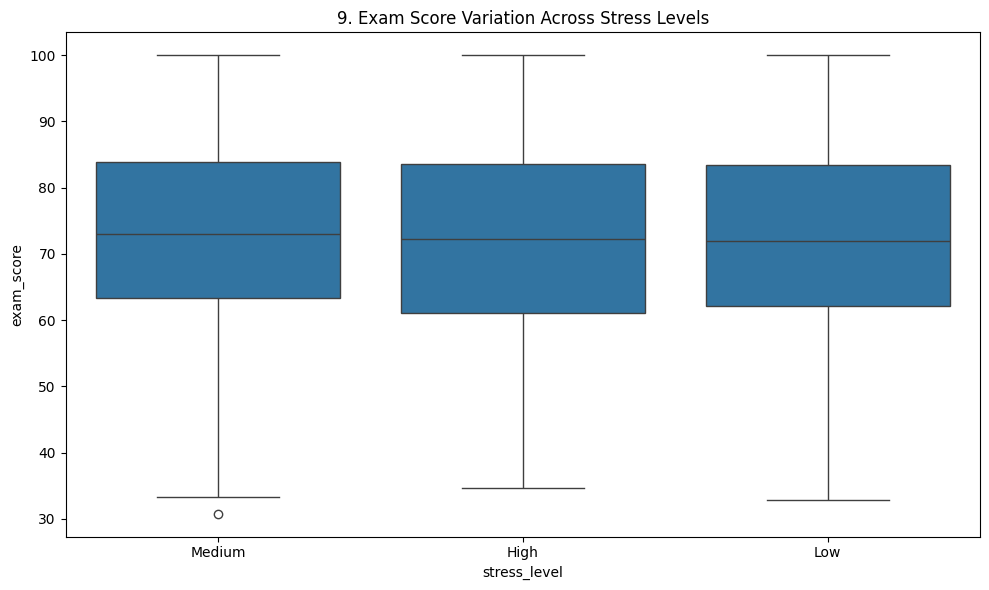

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='stress_level', y='exam_score')
plt.title(f'{plot_no}. Exam Score Variation Across Stress Levels')
show_fig()
plot_no += 1

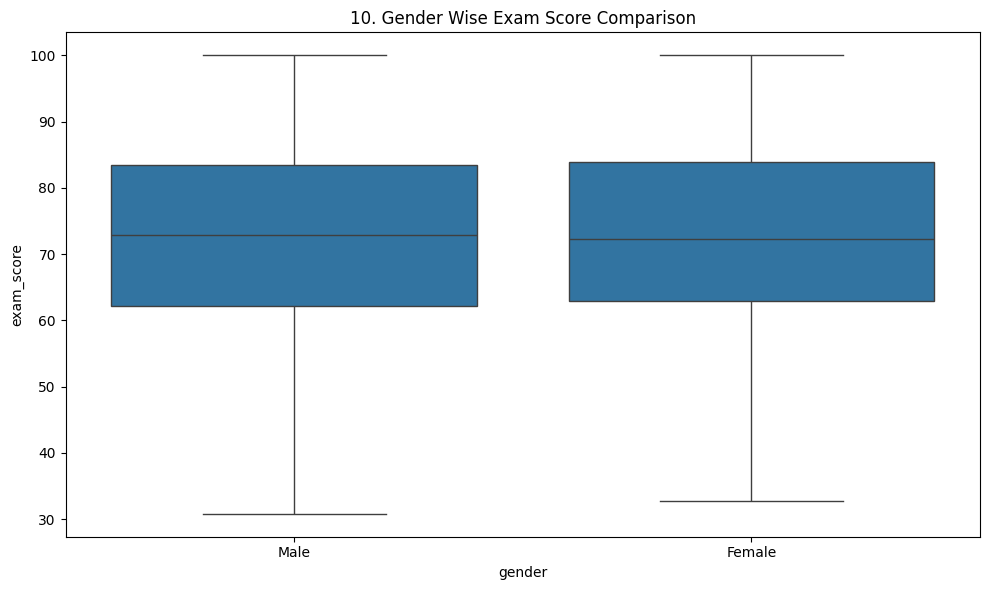

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='gender', y='exam_score')
plt.title(f'{plot_no}. Gender Wise Exam Score Comparison')
show_fig()
plot_no += 1

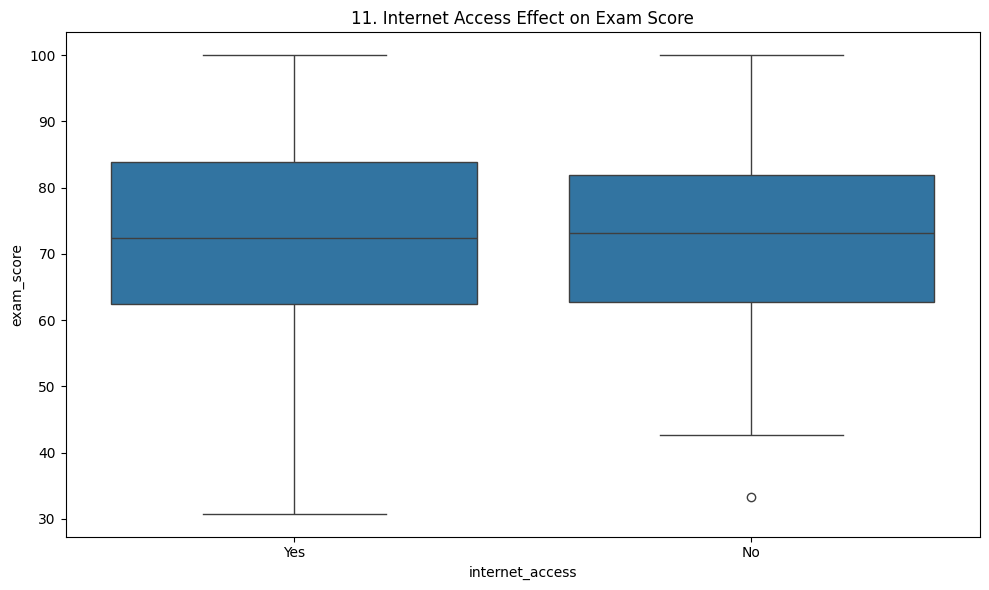

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='internet_access', y='exam_score')
plt.title(f'{plot_no}. Internet Access Effect on Exam Score')
show_fig()
plot_no += 1

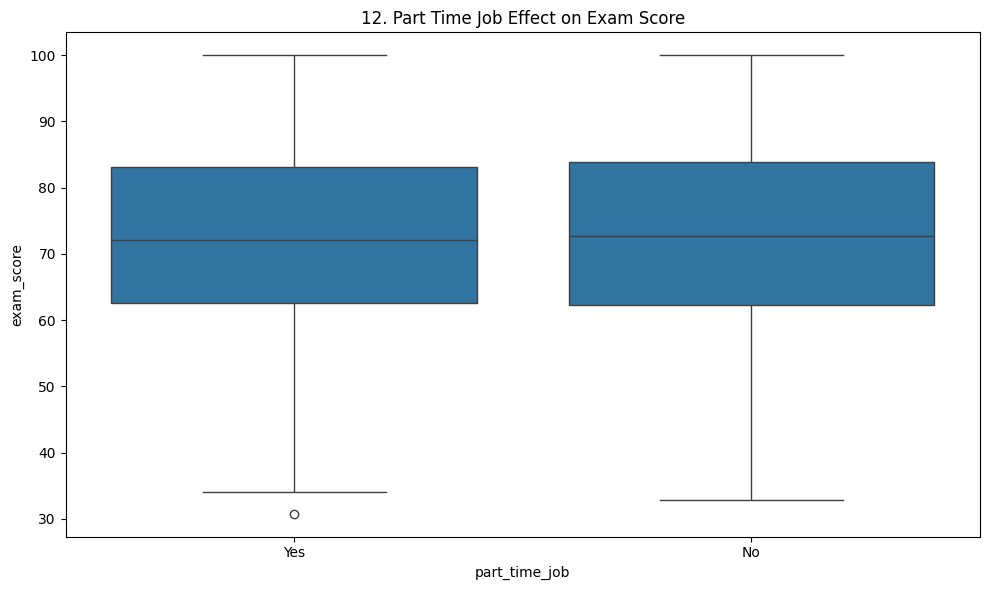

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='part_time_job', y='exam_score')
plt.title(f'{plot_no}. Part Time Job Effect on Exam Score')
show_fig()
plot_no += 1

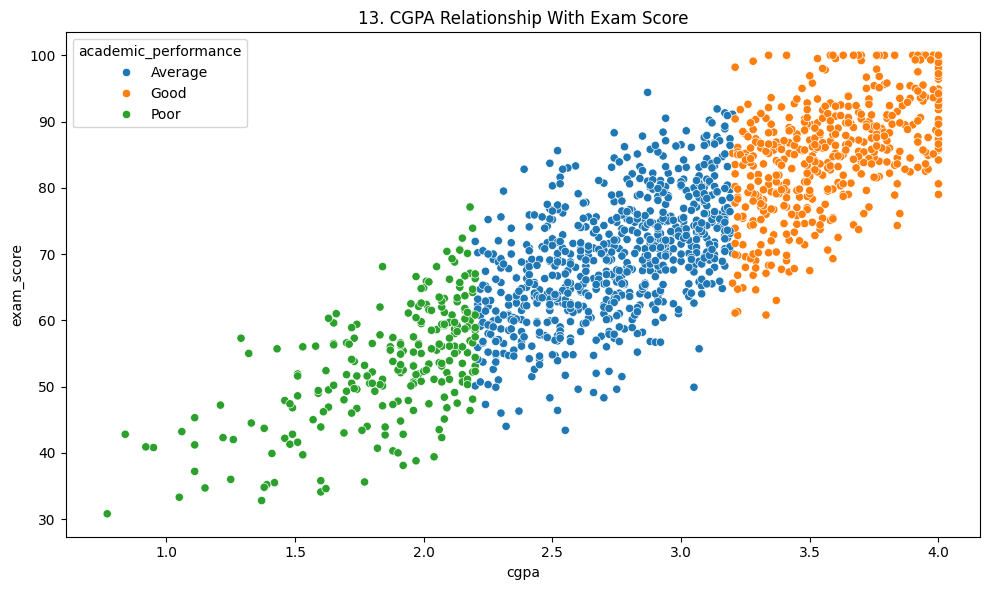

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='cgpa', y='exam_score', hue='academic_performance')
plt.title(f'{plot_no}. CGPA Relationship With Exam Score')
show_fig()
plot_no += 1

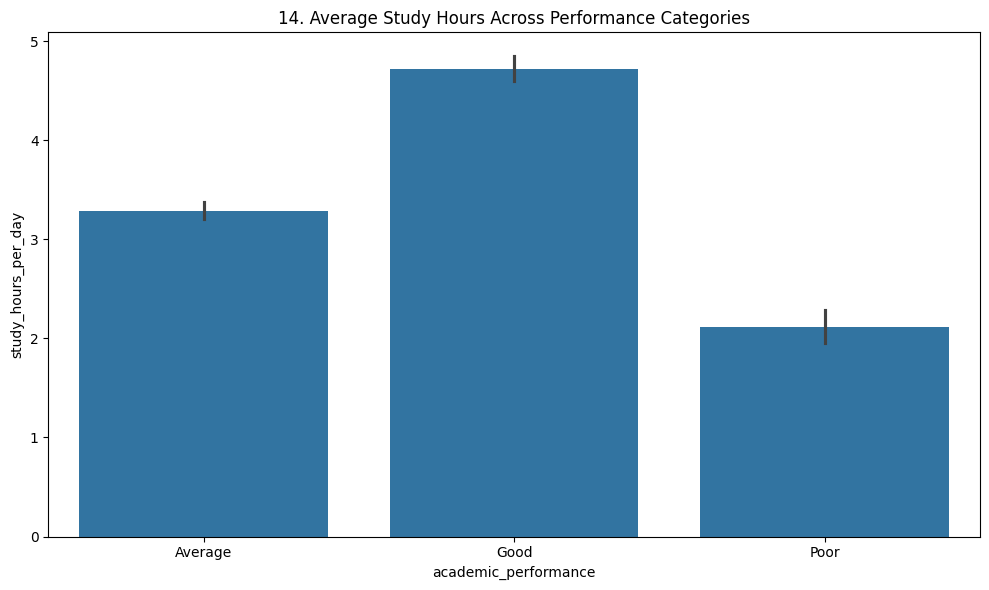

In [27]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='academic_performance', y='study_hours_per_day', estimator='mean')
plt.title(f'{plot_no}. Average Study Hours Across Performance Categories')
show_fig()
plot_no += 1

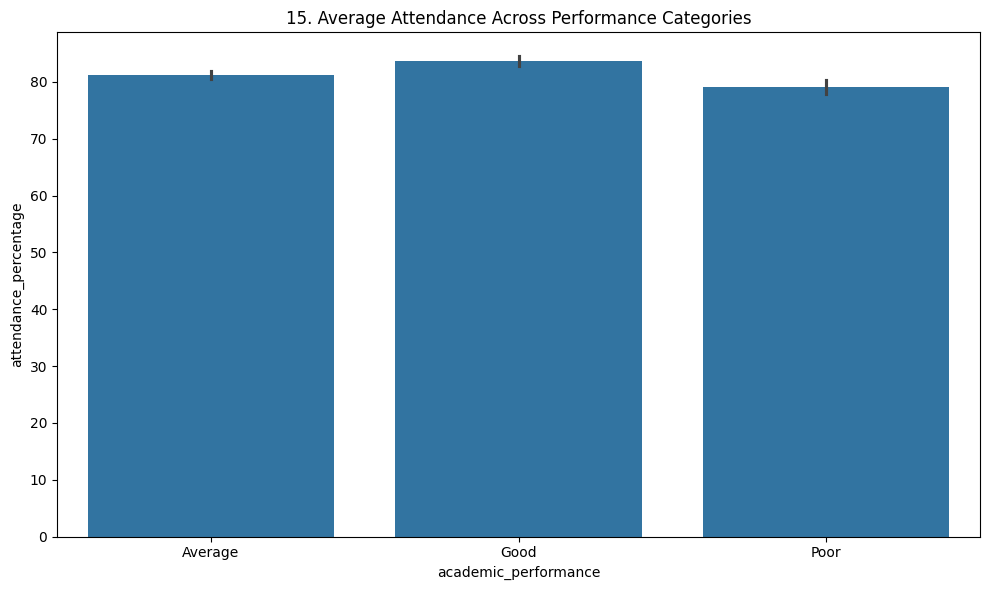

In [28]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='academic_performance', y='attendance_percentage', estimator='mean')
plt.title(f'{plot_no}. Average Attendance Across Performance Categories')
show_fig()
plot_no += 1

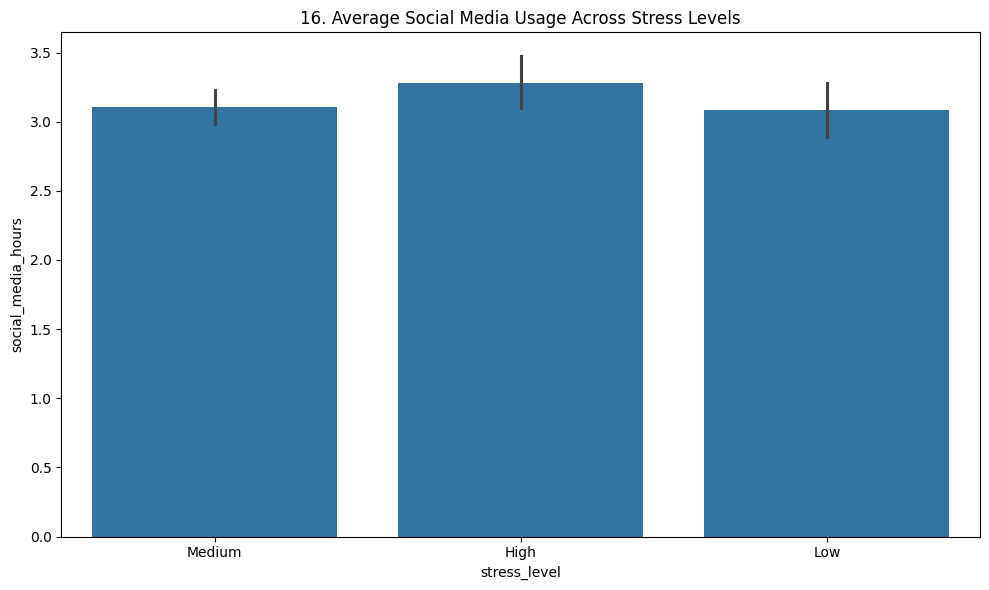

In [29]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='stress_level', y='social_media_hours', estimator='mean')
plt.title(f'{plot_no}. Average Social Media Usage Across Stress Levels')
show_fig()
plot_no += 1

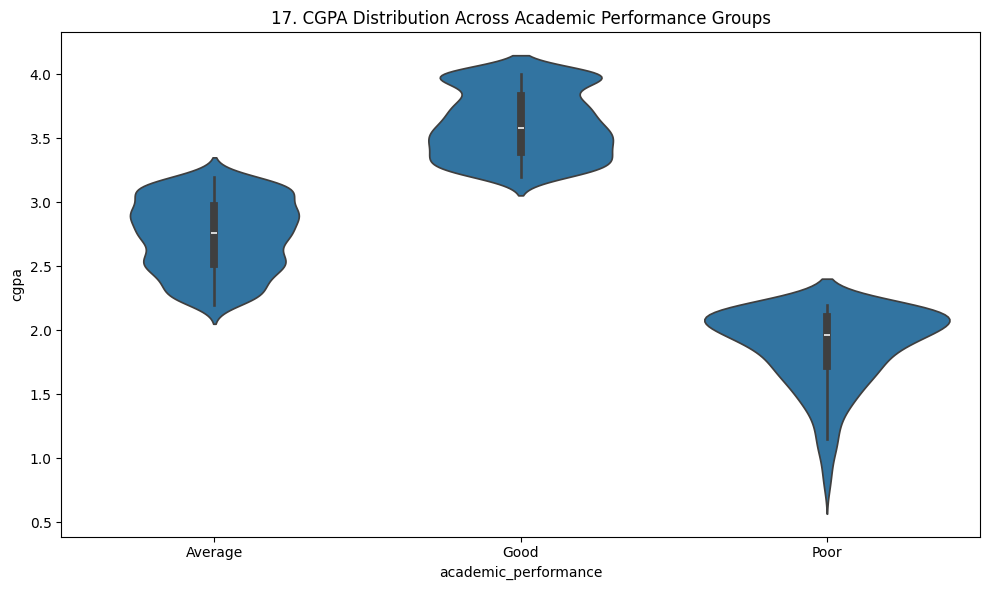

In [30]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='academic_performance', y='cgpa')
plt.title(f'{plot_no}. CGPA Distribution Across Academic Performance Groups')
show_fig()
plot_no += 1

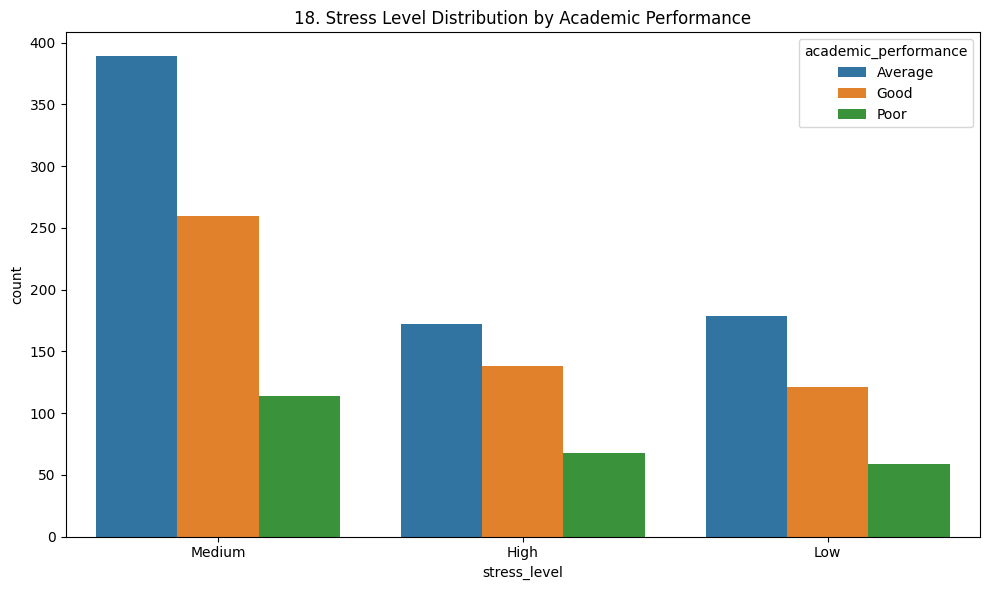

In [31]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='stress_level', hue='academic_performance')
plt.title(f'{plot_no}. Stress Level Distribution by Academic Performance')
show_fig()
plot_no += 1

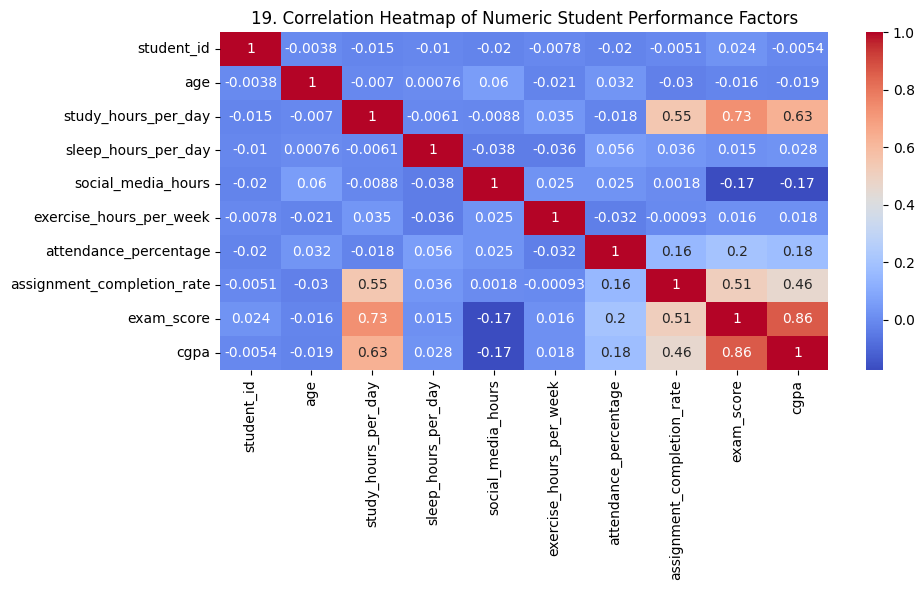

In [32]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numeric Student Performance Factors')
show_fig()
plot_no += 1

# Model Training

## copy dataframe

In [33]:
data = df.copy()

## remove useless id column

In [34]:
data = data.drop(columns=['student_id'], errors='ignore')

## separate features and target

In [35]:
X = data.drop('academic_performance', axis=1)
y = data['academic_performance']

## encode categorical input columns

In [36]:
X = pd.get_dummies(X, drop_first=True)

## encode target column

In [37]:
le = LabelEncoder()
y = le.fit_transform(y)

## split data into train and test

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## create model pipeline with missing value handling, scaling, and model

In [39]:
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000))
])

## train model

In [40]:
model.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('classifier', LogisticRegression(max_iter=1000))])

## predict test data

In [41]:
y_pred = model.predict(X_test)

## print accuracy score

In [42]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.9566666666666667


## print classification report

In [43]:
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Classification Report:
               precision    recall  f1-score   support

     Average       0.94      0.98      0.96       148
        Good       1.00      0.96      0.98       104
        Poor       0.93      0.88      0.90        48

    accuracy                           0.96       300
   macro avg       0.96      0.94      0.95       300
weighted avg       0.96      0.96      0.96       300



## create confusion matrix

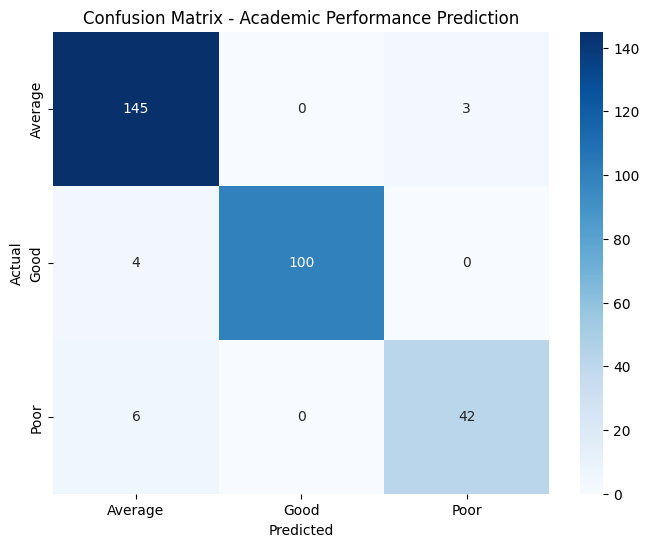

In [44]:
cm = confusion_matrix(y_test, y_pred)

## plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Academic Performance Prediction")
plt.show()